In [97]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import pandas as pd
import scipy

import random


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [98]:
# --- Simulation config ---
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000           # number of time steps
DT = T_HORIZON / (T)   # fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [99]:
# --- Data generation ---

translator = {
    'I': 'Current [A]',
    'V': 'Terminal voltage [V]',
    'cn': 'X-averaged negative particle concentration [mol.m-3]',
    'cp': 'X-averaged positive particle concentration [mol.m-3]',
    'cns': 'X-averaged negative particle surface concentration [mol.m-3]',
    'cps': 'X-averaged positive particle surface concentration [mol.m-3]',
    'ocv': 'Battery open-circuit voltage [V]',
}

translator_inv = {v: k for k, v in translator.items()}

data_cols = ['I', 'V', 'ocv']

def gen_cols(data_cols, translator=translator):
    '''Extracting variable names from translator dict for given data_cols'''
    return [translator[col] for col in data_cols]



def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

def observe_states(t_query, sol, model, data_cols):
    data = pd.DataFrame(index=t_query)
    cols = gen_cols(data_cols)
    for col in cols:
        data[translator_inv[col]] = sol.observe(model.variables[col])(t_query)
    return data

def get_vals_DC(I0,data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_pulse(data_cols=data_cols):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_GRF(data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model


def gen_data(B, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    '''Generate trajectories with shape (B, T, D)'''

    rng = np.random.default_rng(seed)

    dot_cols = [f"{k}_dot" for k in data_cols if k in ['cn','cp']]
    all_cols = data_cols + ['dI'] + dot_cols + ['valid']

    D = len(all_cols)

    X = np.zeros((B, T, D))
    var_index = {k:i for i,k in enumerate(all_cols)}

    for b in trange(B):

        if currents == 'DC':
            data, valid_b, param, sol, model = get_vals_DC(float(rng.uniform(I_low, I_high)))
        elif currents == 'pulse':
            data, valid_b, param, sol, model = get_vals_pulse()
        elif currents == 'GRF':
            data, valid_b, param, sol, model = get_vals_GRF()
        else:
            raise ValueError("Invalid current type")

        # base variables
        for col in data_cols:
            X[b, :, var_index[col]] = data[col].values

        # dI
        if 'I' in data_cols:
            I = data['I'].values
            dI = np.zeros_like(I)
            dI[1:] = np.diff(I)
            X[b, :, var_index['dI']] = dI

        # derivatives
        for col in ['cn','cp']:
            if col in data_cols:
                x = data[col].values
                xdot = np.zeros_like(x)
                xdot[:-1] = np.diff(x) / DT
                xdot[-1] = xdot[-2]
                X[b, :, var_index[f"{col}_dot"]] = xdot

        # valid mask
        X[b, :, var_index['valid']] = valid_b.astype(float)

    return X, var_index


In [100]:
X, var_index = gen_data(2, data_cols, currents='GRF', I_low=0.25, I_high=1.0, seed=42)
print("Data shape:", X.shape)
print("Variable index:", var_index)

100%|██████████| 2/2 [00:05<00:00,  2.60s/it]

Data shape: (2, 1000, 5)
Variable index: {'I': 0, 'V': 1, 'ocv': 2, 'dI': 3, 'valid': 4}


In [102]:
# --- Load data ---
def load_data(path, var_index = var_index):
    with np.load(path) as d:
        X = d['X']  # replace 'X' with the actual key if different

    data = {var: X[:, :, idx] for var, idx in var_index.items()}
    return data


path = f'../3_PHNN_ECM/data_PHNN/data_c_GRF_dt_{T}.npz'
D = load_data(path)
B = 1
I = D['I'][0].ravel(); V = D['V'][0].ravel(); ocv = D['ocv'][0].ravel()
#B = I.shape[0]

#t_fixed = np.vstack([t_fixed]*B)

D['valid'] = D['valid'].astype(bool)


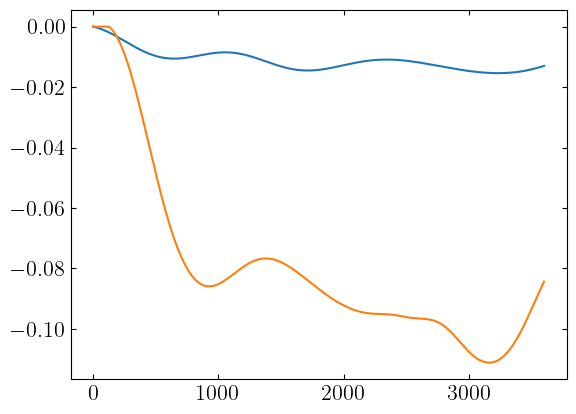

In [101]:
from scipy.interpolate import interp1d

def ECM_solve(theta, i, t):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU(u, t):
        I_t = I_interp(t)
        return -u / (theta[1] * theta[2]) + I_t / theta[2]

    # Solve ODE
    U_sol = scipy.integrate.odeint(dU, 0.0, t)
    U = U_sol.flatten()

    # Voltage model
    eta_model = (- i * theta[0] - U)

    return eta_model

theta_test = np.array([0.01, 0.01, 110])  # Example parameters: R1, C1, R0

eta = ECM_solve(theta_test, I.ravel(), t_fixed.ravel())
plt.plot(t_fixed, eta, label='ECM Voltage')
plt.plot(t_fixed, V - ocv, label='Observed Voltage')

## Bayes

In [103]:
import scipy.stats as stats
import corner
import emcee


# def simulate_II(R1, C1, p=params, coeffs=coeffs_):
#     time, I_list, soc_list, U1_list, V_list, V_soc_list = simulation(p, coeffs)
#     return V_list


def log_prior(theta):
    R0, R1, C1 = theta

    R1_lims = (0.01, 1e4)
    R0_lims = (0.01, 1e4)
    C1_lims = (1, 100000)
    
    p_R0 = stats.uniform.logpdf(R0, loc=R0_lims[0], scale=R0_lims[1] - R0_lims[0])
    p_R1 = stats.uniform.logpdf(R1, loc=R1_lims[0], scale=R1_lims[1] - R1_lims[0])
    p_C1 = stats.uniform.logpdf(C1, loc=C1_lims[0], scale=C1_lims[1] - C1_lims[0])

    #if R0 < R0_lims[0] or R0 > R0_lims[1] or R1 < R1_lims[0] or R1 > R1_lims[1] or or R2 > R2_lims[1] or C1 < C1_lims[0] or C1 > C1_lims[1] or C2 < C2_lims[0] or C2 > C2_lims[1]:
    #    return -np.inf  # Log of zero probability for out-of-bounds parameters
    
    return p_R1 + p_C1 + p_R0

def log_likelihood(theta, i,t, U_obs = V - ocv):
    U_model = ECM_solve(theta,i,t)
    sigma = 0.1  # Assumed standard deviation of the noise
    return stats.norm.logpdf(U_model - U_obs, loc=0, scale=sigma).sum()

def log_posterior(theta,I,t):
    log_post = log_likelihood(theta,I,t) + log_prior(theta)
    
    if np.isnan(log_post):
        return -np.inf
    
    return log_post

In [104]:
def samples_MCMC_II(post,nwalkers = 10, burninproc =10 , iterations = 2500, args = (I, t_fixed)):
    """
    Sets up an MCMC sampler with initial positions for the walkers.

    Args:
        theta_0_lims (list): Minimum and maximum boundary for starting position in theta0.
        theta_1_lims (list): Minimum and maximum boundary for starting position in theta1.
        x (array): Independent data.
        y (array): Dependent data.
        post (callable): Function to compute the log-posterior or log-likelihood.
        nwalkers (int): Number of MCMC walkers.

    Returns:
        sampler (emcee.EnsembleSampler): Initialized MCMC sampler object.
    """
    
    ndim = 3  # Since theta has three parameters:

    rng = np.random.default_rng(seed = 1337)
    ndim = 3  # Since theta has three parameters:

    #rng = np.random.default_rng(seed = 1337)

    R1_lims = (0.001, 1e1)
    R0_lims = (0.001, 100)
    C_lims = (1, 1e5)
    R0   = np.random.uniform(R0_lims[0],R0_lims[1],size = nwalkers)
    R1   = np.random.uniform(R1_lims[0],R1_lims[1],size = nwalkers)
    C1   = np.random.uniform(C_lims[0],C_lims[1],size = nwalkers)
    
    p0 = np.vstack((R0,R1,C1)).T
    burnin = int(burninproc*iterations/100)

    # Set up the MCMC sampler with the log posterior function
    sampler_post = emcee.EnsembleSampler(nwalkers, ndim, post, args=args)
    new_pos, prob, state = sampler_post.run_mcmc(p0, burnin, progress=True)

    run = sampler_post.run_mcmc(new_pos, iterations, progress=True)
    samples = sampler_post.get_chain(flat = True)

    return samples

In [105]:
samples = samples_MCMC_II(log_posterior)

100%|██████████| 2500/2500 [00:44<00:00, 55.82it/s]


In [106]:
burned_samples = samples[:10 * len(samples) // 100] 
samples = samples[10 * len(samples) // 100:]

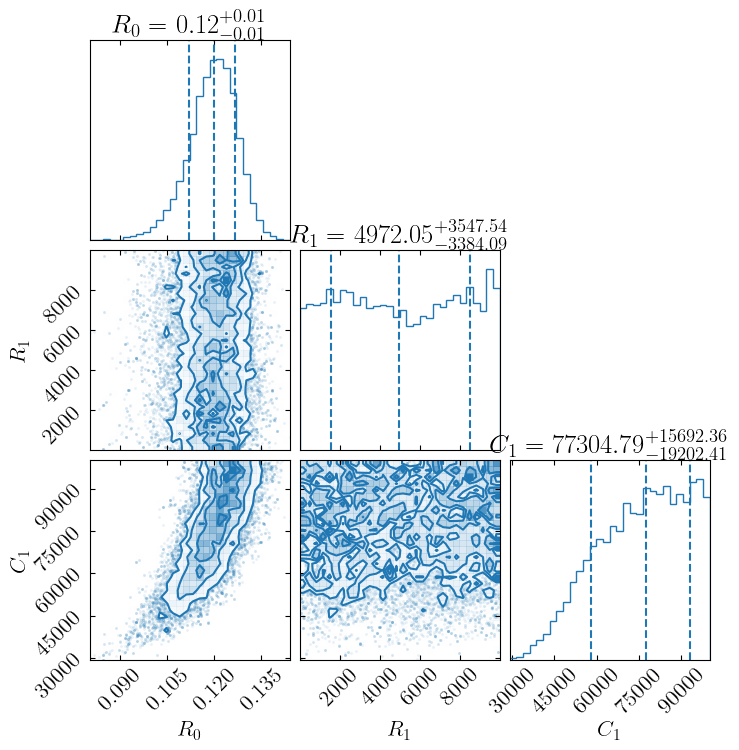

In [107]:
fig = corner.corner(samples, labels=[r"$R_0$",r"$R_1$",r"$C_1$"], color='tab:blue',
                show_titles=True, bins=30, plot_contours=True, plot_datapoints=True, 
                plot_density=True,quantiles=[0.16,0.5,0.84])

In [108]:
def running_mean(x, factor=0.01):
    """
    Return the running mean of N element in a list.

    Args:
        x (ndarray): The list of elements,
        factor (float): The factor to multiply the length of the list by.
    
    Returns:
        ndarray: The running mean.
    """
    it, walker = x.shape
    N = int(factor * it)
    average = np.zeros((it - N+1,walker))

    for i in range(walker):
        cumsum = np.cumsum(np.insert(x[:,i], 0, 0))
        average[:,i] = ((cumsum[N:] - cumsum[:-N]) / float(N))

    return average


def trace_plotter(samples):
    ndim = samples.shape[1]
    fig, axes = plt.subplots(ndim, figsize=(5, 6), sharex=True)
    labels = [r"$R_0$", r"$R_1$",r"$C_1$",r"$C_2$"]
    mean = running_mean(samples)
    if ndim == 1:
        axes.plot(samples, "tab:blue", alpha=0.7)
        axes.plot(np.arange(len(mean)), mean, color='tab:red')
        axes.tick_params(direction='in')
        axes.set_ylabel('$\\Omega_{M,0}$')
        axes.set_xlabel("step number");
    else:
        for i,ax in zip(range(ndim),axes):
            ax.plot(samples[:, i], "tab:blue", alpha=0.7)
            ax.plot(np.arange(len(mean)), mean[:,i], color='tab:red')
            ax.set_ylabel(labels[i])
            ax.tick_params(direction='in')

        axes[-1].set_xlabel("step number");
    plt.tight_layout()
    plt.savefig('ECM_figs/ECM_trace_plot.pdf')
    plt.show()

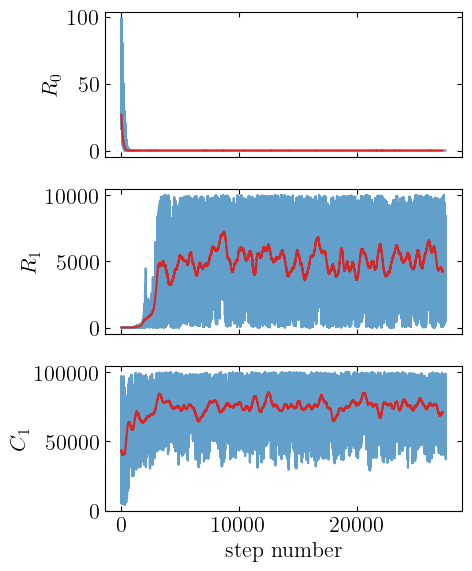

In [109]:
trace_plotter(np.vstack((burned_samples,samples)))

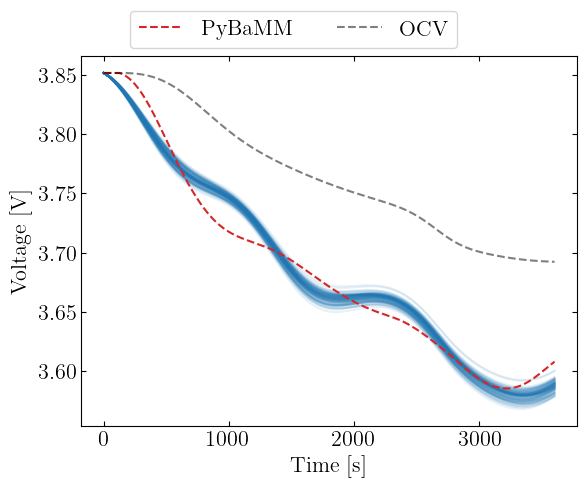

In [110]:
Nsamp = 100
sample_idx = random.sample(range(0, len(samples)), Nsamp)
f, ax = plt.subplots()
U_true = V


for i in sample_idx:
    ax.plot(t_fixed,ECM_solve(samples[i],I,t_fixed) + ocv, color='tab:blue', alpha=0.1)


#    plt.plot(*simulate_II(*samples[i]), color='tab:blue', alpha=0.1)
#plt.plot(t,model_II(samples[i]), color='tab:blue', alpha=0.1, label = 'ECM samples')
ax.plot(t_fixed,U_true, label = 'PyBaMM', linestyle = '--',color = 'tab:red')
ax.plot(t_fixed,ocv, color='black', alpha=0.5, label = 'OCV', linestyle = '--'   )
#plt.plot(t,V_soc(SOC(i0)), label = 'SOC', linestyle = '--',color = 'tab:green')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')
f.legend(ncol = 3, loc = 'upper center')



NameError: name 'V_pybamm' is not defined

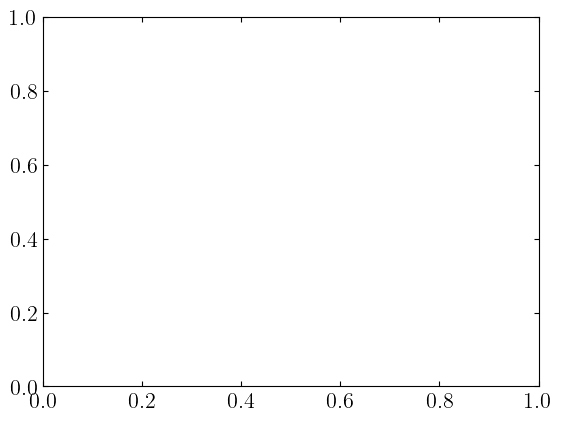

In [111]:
Nsamp = 100
sample_idx = random.sample(range(0, len(samples)), Nsamp)
f, ax = plt.subplots()

U_true = V_pybamm
axt = ax.twinx()
axt.plot(t,V_soc_poly(simulate_II([0.15,122,38499])[1],coeffs_), label='OCV', color = 'black',alpha = 0.5)
axt.set_ylabel('OC Voltage [V]')

for i in sample_idx:
    ax.plot(t,model_II(samples[i]), color='tab:blue', alpha=0.1)


#    plt.plot(*simulate_II(*samples[i]), color='tab:blue', alpha=0.1)
#plt.plot(t,model_II(samples[i]), color='tab:blue', alpha=0.1, label = 'ECM samples')
ax.plot(t,model_II(samples[i]), color='tab:blue', alpha=1, label = 'ECM samples')
ax.plot(t,U_true, label = 'PyBaMM', linestyle = '--',color = 'tab:red')
#plt.plot(t,V_soc(SOC(i0)), label = 'SOC', linestyle = '--',color = 'tab:green')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')
f.legend(ncol = 3, loc = 'upper center')

#plt.savefig('ECM_figs/ECM_MAP_I_vary_preds.pdf', bbox_inches='tight')